## Prepare dataset

In [14]:
DATASET_NAME = "IXI_COW_S"
DATA_PATH = "/data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic"

#these functions are to define for each new dataset, unless fixing a rule
#they allow to define a clear association between the data path of a brain image and the corresponding brain/vessel mask
#the brain mask is not mandatory, if not present just return None
import utils
def img_path_to_brain_path(img_path):
    out_path =img_path.replace("/images","/brain")
    return out_path
def img_path_to_vessel_path(img_path):
    out_path =img_path.replace("/images","/labels")
    return out_path
def img_path_to_weight_path(img_path):
    return None

utils.img_path_to_brain_path = img_path_to_brain_path
utils.img_path_to_vessel_path = img_path_to_vessel_path
utils.img_path_to_weight_path = img_path_to_weight_path

#this regex works as a filter in case you have unnecessary .nii files in your dataset folder
PATH_RULE = "^.*MRA.nii.gz$"
PATH_RULE = ".*/images(Tr|Ts)/.*.nii.gz$"

#if you have some outliers you want to discard, you can specify it in the list below
OUTLIERs = ['IXI371-IOP-0970-MRA.nii.gz']

#if you need to preprocess also images with no vessel masks set the following flag to False
VESSELs_REQUIRED = False

#this parameter is to unify the orientation of our images
#set it True if you notice in the examples shown below that the nose is oriented downward and not upward
utils.do_flip = False

### Extract paths

In [15]:
import os

from utils import search_nii, extract_paths, load_info_from_checkpoint

In [16]:
import os 
if not os.path.isfile(f"info_{DATASET_NAME}.pkl"):
    info = {
        "train": extract_paths(path_rule=PATH_RULE),
        "val": None,
        "test": None
    }
    search_nii(DATA_PATH, info["train"])
else:
    info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

Path /data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic/labelsTr/IXI002-Guys-0828-MRA_topcow_090.nii.gz does not match the rule .*/images(Tr|Ts)/.*.nii.gz$
Path /data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic/labelsTr/IXI012-HH-1211-MRA_topcow_091.nii.gz does not match the rule .*/images(Tr|Ts)/.*.nii.gz$
Path /data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic/labelsTr/IXI013-HH-1212-MRA_topcow_092.nii.gz does not match the rule .*/images(Tr|Ts)/.*.nii.gz$
Path /data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic/labelsTr/IXI015-HH-1258-MRA_topcow_093.nii.gz does not match the rule .*/images(Tr|Ts)/.*.nii.gz$
Path /data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic/labelsTr/IXI016-Guys-0697-MRA_topcow_094.nii.gz does not match the rule .*/images(Tr|Ts)/.*.nii.gz$
Path /data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic/labelsTr/IXI017-Guys-0698-MRA_topcow_095.nii.gz does not match the rule .*/images(Tr|Ts)/.*.nii.gz$
Path /data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stoc

### Display examples

In [17]:
try:
    print(len(info["test"].paths))
except:
    print(len(info["train"].paths))

112


In [18]:
import random

from utils import print_bold, load_and_display_middle_slice

[Example 01]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 54
dim             : [  3 520 576 184   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.         0.296875   0.296875   0.60000455 1.         1.
 1.         1.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'TE=3.4;Time=101937.067'
aux_file        : b''
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.041193478
quatern_c       : -0.002328013
quatern_d       : 0.9990949
qoffs

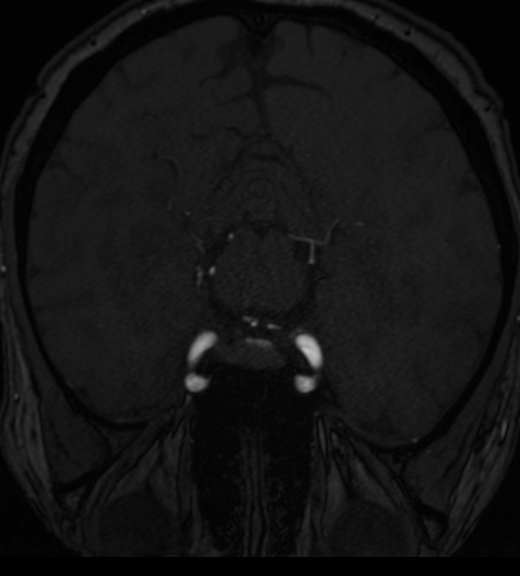

[Example 02]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 512 512 100   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.         0.46875    0.46875    0.7999994  0.         0.
  0.         0.       ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'MR'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.027279263
quatern_c       : -0.9994637
quatern_d       : -0.018108742
qoffset_x       : 130.50

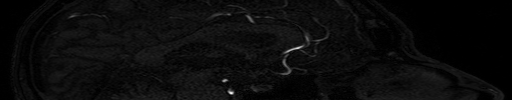

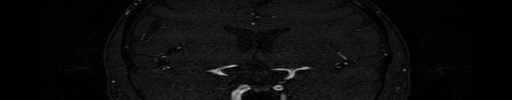

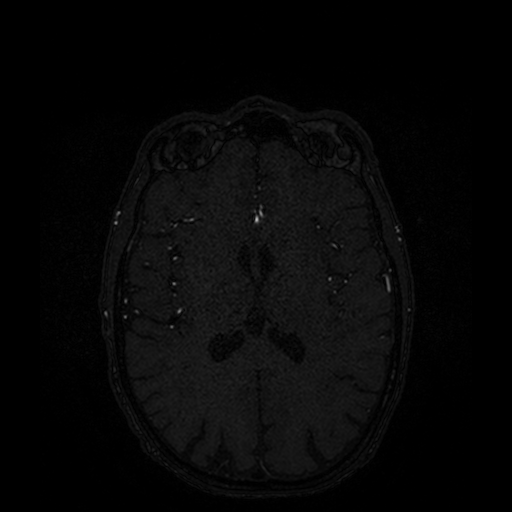

In [19]:
print_bold("[Example 01]")
random.seed(0)
load_and_display_middle_slice(random.choice(info["train"].paths), display_header=True)

print_bold("[Example 02]")
random.seed(1)
load_and_display_middle_slice(random.choice(info["train"].paths), axis=[0,1,2], display_header=True)

### Split train/val/test

In [20]:
from utils import is_medical_volume

In total, there are

In [21]:
IMGs = sum([
    info["train"].paths,
    info["val"].paths if info["val"] is not None else [],
    info["test"].paths if info["test"] is not None else []
], [])

len(IMGs)

112

volumes. First, we discard the outliers:

In [22]:
IMGs = [img_path for img_path in IMGs if os.path.basename(img_path) not in OUTLIERs]

len(IMGs)

112

We have vessel annotations for

In [23]:
HAVE_VESSELs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_vessel_path(img_path))
]


len(HAVE_VESSELs)

112

of them. With a chosen ratio of 70-15-15, we select

In [24]:
COUNT_TEST = 4
COUNT_TEST

4

images to be part of the validation/testing set.

In case brain masks are available, we collect them too.

In [25]:
HAVE_BRAINs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_brain_path(img_path))
]

len(HAVE_BRAINs)

0

Finally, we randomly split our dataset. 

In [26]:
random.seed(0)

# all the HAVE_VESSELs that have imagesTs in their path
TEST_IMGs = [img for img in (HAVE_VESSELs if VESSELs_REQUIRED else IMGs) if "imagesTs" in img]
print("test: ", [os.path.basename(img) for img in TEST_IMGs])


random.seed(1)
# COUNT_TEST random HAVE_VESSELs that are not in TEST_IMGs
VAL_IMGs = random.sample([img for img in HAVE_VESSELs if img not in TEST_IMGs], COUNT_TEST)
print("val: ")
for img in VAL_IMGs:
    print(img)

TRAIN_IMGs = [img for img in (HAVE_VESSELs if VESSELs_REQUIRED else IMGs) if img not in VAL_IMGs and img not in TEST_IMGs]
print("train: ")
for img in TRAIN_IMGs:
    print(img)

f"Len train: {len(TRAIN_IMGs)}, Len val: {len(VAL_IMGs)}, Len test: {len(TEST_IMGs)}"

test:  ['topcow_mr_whole_000.nii.gz', 'topcow_mr_whole_001.nii.gz', 'topcow_mr_whole_002.nii.gz', 'topcow_mr_whole_003.nii.gz', 'topcow_mr_whole_004.nii.gz', 'topcow_mr_whole_005.nii.gz', 'topcow_mr_whole_006.nii.gz', 'topcow_mr_whole_007.nii.gz', 'topcow_mr_whole_008.nii.gz', 'topcow_mr_whole_009.nii.gz', 'topcow_mr_whole_010.nii.gz', 'topcow_mr_whole_011.nii.gz', 'topcow_mr_whole_012.nii.gz', 'topcow_mr_whole_013.nii.gz', 'topcow_mr_whole_014.nii.gz', 'topcow_mr_whole_015.nii.gz', 'topcow_mr_whole_016.nii.gz', 'topcow_mr_whole_017.nii.gz', 'topcow_mr_whole_018.nii.gz', 'topcow_mr_whole_019.nii.gz', 'topcow_mr_whole_020.nii.gz', 'topcow_mr_whole_021.nii.gz', 'topcow_mr_whole_022.nii.gz', 'topcow_mr_whole_023.nii.gz', 'topcow_mr_whole_024.nii.gz', 'topcow_mr_whole_025.nii.gz', 'topcow_mr_whole_026.nii.gz', 'topcow_mr_whole_027.nii.gz', 'topcow_mr_whole_028.nii.gz', 'topcow_mr_whole_029.nii.gz', 'topcow_mr_whole_030.nii.gz', 'topcow_mr_whole_031.nii.gz', 'topcow_mr_whole_032.nii.gz', 't

'Len train: 18, Len val: 4, Len test: 90'

In [27]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Extract spacings and shapes

In [28]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [29]:
from utils import extract_info_and_masks, loop_nii, display_info, get_target_spacing

In [30]:
info = {
    "train": extract_info_and_masks(path_rule=PATH_RULE),
    "val": extract_info_and_masks(path_rule=PATH_RULE),
    "test": extract_info_and_masks(path_rule=PATH_RULE),
}

loop_nii(TRAIN_IMGs, info["train"])
loop_nii(VAL_IMGs, info["val"])
loop_nii(TEST_IMGs, info["test"])

In [31]:
try:
    display_info(info["train"], info["val"])
except Exception as e:
     display_info(info["train"])

,#volumes,#slices,spacing median,spacing range,shape median,shape range
TRAIN,18,1776,[000.47 000.47 000.80],[000.26 000.26 000.80] - [000.47 000.47 000.80],[367.00 487.50 100.00],[321.00 433.00 092.00] - [653.00 870.00 100.00]
VAL,4,400,[000.47 000.47 000.80],[000.47 000.47 000.80] - [000.47 000.47 000.80],[359.00 497.50 100.00],[350.00 482.00 100.00] - [365.00 512.00 100.00]


In [32]:
SPACING = get_target_spacing(
    info["train"].spacings + info["val"].spacings,
    info["train"].shapesAfterCropping() + info["val"].shapesAfterCropping()
)

SPACING

array([0.46875   , 0.46875   , 0.79999992])

In [33]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Crop, Metadata, Resize, Empty Slices Removal, Standardization

In [34]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [35]:
import os

from utils import print_bold, preprocessing_loop

In [36]:
from pathlib import Path


OUT_DIR = "/data/falcetta/A2V_experiments/IXI_COW_preprocessed"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

In [ ]:
print_bold("Training")
preprocessing_loop(
    info["train"],
    os.path.join(OUT_DIR,"numpy", "train"),
    target_spacing=SPACING
    
)

print_bold("Validation")
preprocessing_loop(
    info["val"],
    os.path.join(OUT_DIR,"numpy", "val"),
    target_spacing=SPACING
)

print_bold("Testing")
preprocessing_loop(
    info["test"],
    os.path.join(OUT_DIR,"numpy", "test"),
    target_spacing=SPACING
)

Training


  0%|          | 0/18 [00:00<?, ?it/s]

(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875   0.46875   0.7999998]
PASSED New shape: [512, 512]
New shape: [512 512 100]
Resized shape: (512, 512, 100)


  6%|▌         | 1/18 [00:12<03:40, 12.96s/it]

Slices processed: 100
(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875    0.46875    0.79999995]
PASSED New shape: [512, 512]
New shape: [512 512 100]


  6%|▌         | 1/18 [00:20<05:45, 20.32s/it]


KeyboardInterrupt: 

In [31]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Outliers removal and slices extraction

In [32]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [33]:
import os

from utils import print_bold, extraction_loop, display_slice

In [34]:
print_bold("Training")
extraction_loop(
    info["train"],
    os.path.join(OUT_DIR,"slices", "train")
)

print_bold("Validation")
extraction_loop(
    info["val"],
    os.path.join(OUT_DIR,"slices", "val")
)

print_bold("Testing")
extraction_loop(
    info["test"],
    os.path.join(OUT_DIR,"slices", "test")
)

Training


  0%|          | 0/18 [00:00<?, ?it/s]

100%|██████████| 18/18 [00:14<00:00,  1.22it/s]


Validation


100%|██████████| 4/4 [00:04<00:00,  1.11s/it]


Testing


100%|██████████| 519/519 [19:07<00:00,  2.21s/it]


In [35]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Intensity values analysis

In [36]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [37]:
import numpy as np

from utils import intensity_loop, display_intensity
from utils import get_percentile, display_clipped_slice

Training


100%|██████████| 18/18 [00:34<00:00,  1.90s/it]


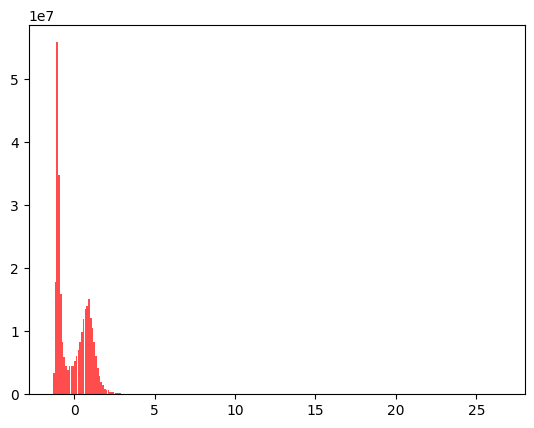

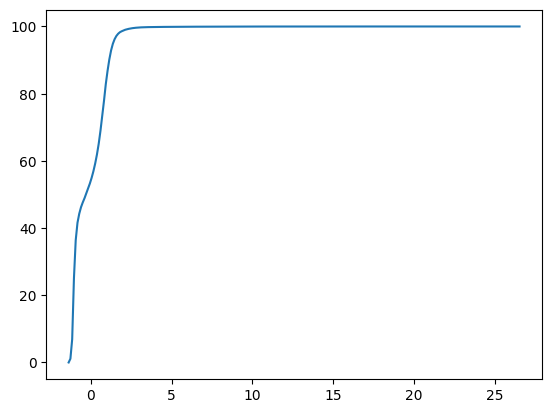

Validation


100%|██████████| 4/4 [00:04<00:00,  1.24s/it]


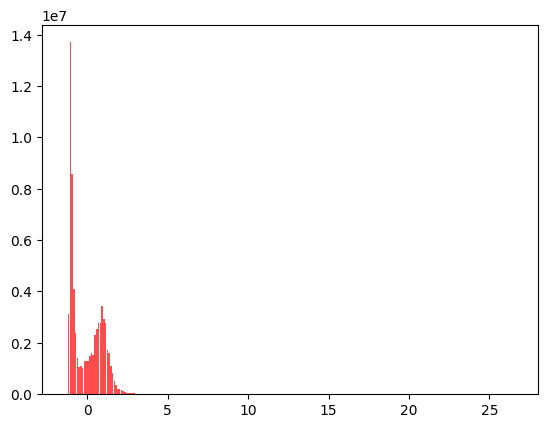

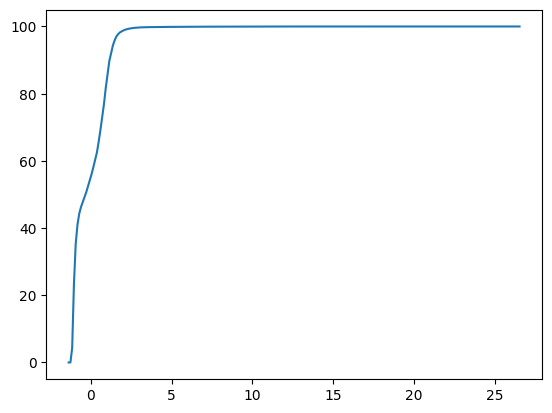

In [38]:
print_bold("Training")
intensity_loop(
    info["train"],
    min_value=min(info["train"].min_values + info["val"].min_values),
    max_value=max(info["train"].max_values + info["val"].max_values)
)
display_intensity(info["train"])

print_bold("Validation")
intensity_loop(
    info["val"],
    min_value=min(info["train"].min_values + info["val"].min_values),
    max_value=max(info["train"].max_values + info["val"].max_values)
)
display_intensity(info["val"])

In [39]:
MIN_VALUE = get_percentile(
    info["train"].bins,
    info["train"].intensity_count + info["val"].intensity_count,
    0.1
)
MAX_VALUE = get_percentile(
    info["train"].bins,
    info["train"].intensity_count + info["val"].intensity_count,
    99.9
)

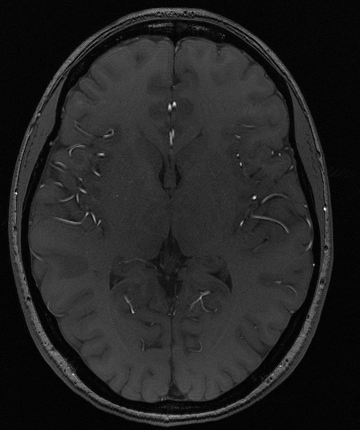

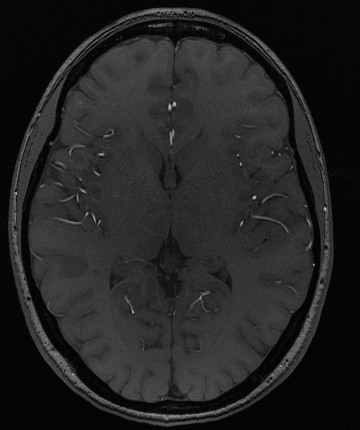

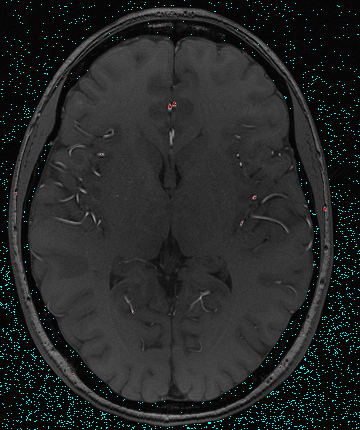

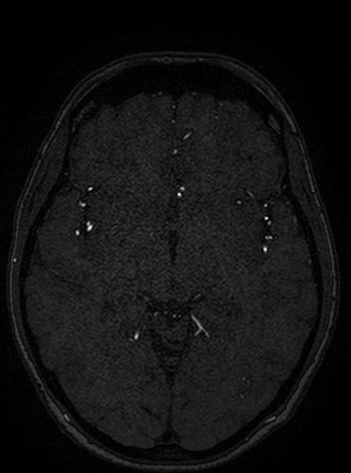

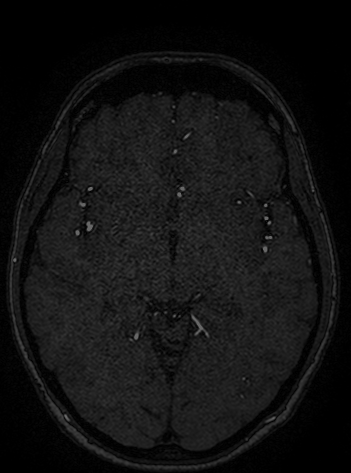

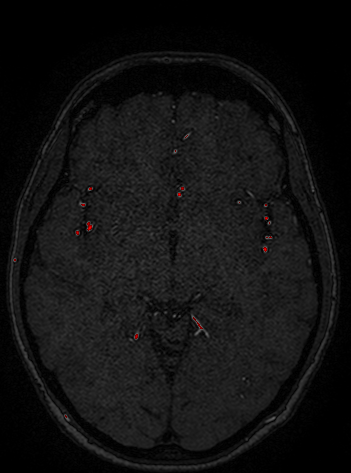

In [40]:
min_values_idx = np.argmin(
    info["train"].min_values + info["val"].min_values
)
DARK = (info["train"].preprocessed_paths + info["val"].preprocessed_paths)[min_values_idx]
DARK = DARK.replace("numpy/", "slices/").replace(".npy", "_slice{:03d}.npy").format(50)
display_clipped_slice(DARK, MIN_VALUE, MAX_VALUE)

max_values_idx = np.argmax(
    info["train"].max_values + info["val"].max_values
)
BRIGHT = (info["train"].preprocessed_paths + info["val"].preprocessed_paths)[max_values_idx]
BRIGHT = BRIGHT.replace("numpy/", "slices/").replace(".npy", "_slice{:03d}.npy").format(50)
display_clipped_slice(BRIGHT, MIN_VALUE, MAX_VALUE)

In [41]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Normalization, Padding & Cropping, One-Hot Encoding

In [42]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [43]:
import numpy as np

from utils import display_slice, normalization_loop

In [44]:
print_bold("Training")
normalization_loop(info["train"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/train", MIN_VALUE, MAX_VALUE)#, delete_old=False)#TO DELETE

print_bold("Validation")
normalization_loop(info["val"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/val", MIN_VALUE, MAX_VALUE)#, delete_old=False)#TO DELETE

print_bold("Testing")
normalization_loop(info["test"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/test", MIN_VALUE, MAX_VALUE)#, delete_old=False)#TO DELETE

Training


100%|██████████| 18/18 [00:25<00:00,  1.42s/it]


Validation


100%|██████████| 4/4 [00:05<00:00,  1.47s/it]


Testing


100%|██████████| 519/519 [32:09<00:00,  3.72s/it]


In [45]:
np.save(f"preprocess_map_{DATASET_NAME}.npy", {
    "train": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/train")),
    "val": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/val")),
    "test": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/test")),
})

In [46]:
img_example = np.load(
    f"preprocess_{DATASET_NAME}/train/IXI002-Guys-0828-MRA_slice090.npy", allow_pickle=True
).item()

img_example, msk_example = img_example["data"][:,:,0], img_example["mask"]

msk_example = np.argmax(msk_example, axis=-1)

display_slice(img_example, min_val=-1, max_val=1, mask=msk_example/2)

FileNotFoundError: [Errno 2] No such file or directory: 'preprocess_IXI/train/IXI002-Guys-0828-MRA_slice090.npy'